In [1]:
!pip install pandas scikit-learn openpyxl joblib

In [2]:
import pandas as pd

df_test = pd.read_excel('testwise_report_2025.xlsx')
df_detail = pd.read_excel('detail_report_2025.xlsx')

In [3]:
df = pd.merge(
    df_test,
    df_detail,
    on='form6_barcode',
    how='left'
)

In [4]:
# Convert dates
date_cols = [
    'received_datetime','issued_datetime','reported_datetime',
    'parcel_date','form6_date','form7_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Remove duplicates (important in DTMS)
df = df.drop_duplicates()

# Fill missing
df = df.fillna('Unknown')

In [6]:
df['tat_days'] = (
    pd.to_datetime(df['reported_datetime'], errors='coerce') -
    pd.to_datetime(df['received_datetime'], errors='coerce')
).dt.days

In [7]:
target = 'is_delayed'

In [9]:
categorical_cols = [col for col in [
    'test_title',
    'generic_name',
    'manufacturer',
    'drug_form',
    'sample_mode'
] if col in df.columns]

In [13]:
# Ensure target exists
if 'is_delayed' not in df.columns:
    df['tat_days'] = (
        pd.to_datetime(df['reported_datetime'], errors='coerce') -
        pd.to_datetime(df['received_datetime'], errors='coerce')
    ).dt.days

    df['is_delayed'] = (df['tat_days'] > 30).astype(int)

# Define target
target = 'is_delayed'

# Select only available features
features = [col for col in [
    'test_title',
    'generic_name',
    'manufacturer',
    'drug_form',
    'sample_mode',
    'days_in_dtl',
    'test_count',
    'test_complexity'
] if col in df.columns]

# Final dataset
X = df[features]
y = df[target]

In [15]:
# Convert ALL text columns to numbers
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Train model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=150)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=150)

In [16]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9311382249707505
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      5526
           1       0.57      0.41      0.48       457

    accuracy                           0.93      5983
   macro avg       0.76      0.69      0.72      5983
weighted avg       0.92      0.93      0.93      5983



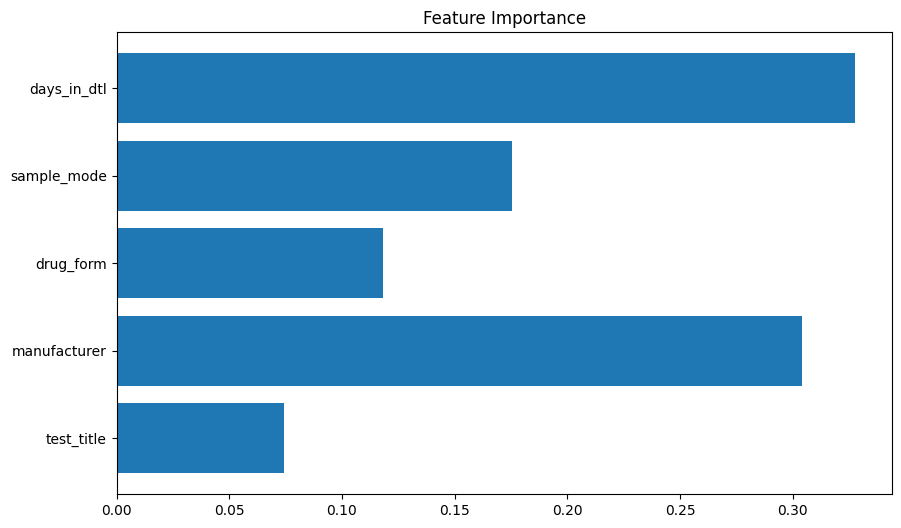

In [17]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [18]:
import joblib

joblib.dump(model, 'dtms_model.pkl')

['dtms_model.pkl']

In [19]:
from google.colab import files
files.download('dtms_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
sample = X_test.iloc[0:1]

prediction = model.predict(sample)

print("Prediction:", prediction)
print("Actual:", y_test.iloc[0])

Prediction: [0]
Actual: 1
